In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression

In [2]:
balanced_year_datas = []
for year in range(1997, 2007):
    yearly_data = pd.read_csv(f'./Plane Data/{year}.csv', encoding='latin-1', dtype={"CancellationCode": object})
    diverted_year_data = yearly_data[yearly_data['Diverted'] == 1] 
    non_diverted_year_data = yearly_data[yearly_data['Diverted'] == 0].sample(n=diverted_year_data.shape[0])
    balanced_year_datas.append(pd.concat([diverted_year_data, non_diverted_year_data]))

airport_data = pd.read_csv('./Plane Data/airports.csv', encoding='latin-1')

In [3]:
complete_datas = []
for data in balanced_year_datas:
    complete_data = data.merge(airport_data, left_on='Origin', right_on='iata', how='left')
    complete_data = complete_data.merge(airport_data, left_on='Dest', right_on='iata', how='left', suffixes=('_origin', '_dest'))

    complete_datas.append(complete_data)

complete_datas[0]


,Year,Month,DayofMonth,DayOfWeek,DepTime,CRSDepTime,ArrTime,CRSArrTime,UniqueCarrier,FlightNum,...,country_origin,lat_origin,long_origin,iata_dest,airport_dest,city_dest,state_dest,country_dest,lat_dest,long_dest
0,1997,1,13,1,1142.0,1020,NaN,1130,WN,1293,...,USA,35.040222,-106.609194,PHX,Phoenix Sky Harbor International,Phoenix,AZ,USA,33.434167,-112.008056
1,1997,1,4,6,1505.0,1415,NaN,1535,WN,743,...,USA,30.194533,-97.669872,PHX,Phoenix Sky Harbor International,Phoenix,AZ,USA,33.434167,-112.008056
2,1997,1,6,1,1256.0,1300,NaN,1505,DL,159,...,USA,39.046143,-84.662172,PHX,Phoenix Sky Harbor International,Phoenix,AZ,USA,33.434167,-112.008056
3,1997,1,7,2,805.0,630,NaN,740,WN,1710,...,USA,31.806667,-106.377806,PHX,Phoenix Sky Harbor International,Phoenix,AZ,USA,33.434167,-112.008056
4,1997,1,26,7,942.0,935,NaN,1311,CO,1915,...,USA,40.692497,-74.168661,PHX,Phoenix Sky Harbor International,Phoenix,AZ,USA,33.434167,-112.008056
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24157,1997,1,25,6,1115.0,1105,1353.0,1349,UA,280,...,USA,41.979595,-87.904464,ATL,William B Hartsfield-Atlanta Intl,Atlanta,GA,USA,33.640444,-84.426944
24158,1997,3,17,1,758.0,800,1541.0,1555,CO,192,...,USA,33.675659,-117.868223,EWR,Newark Intl,Newark,NJ,USA,40.692497,-74.168661
24159,1997,5,31,6,938.0,940,1025.0,1040,NW,1233,...,USA,39.997985,-82.891883,MSP,Minneapolis-St Paul Intl,Minneapolis,MN,USA,44.880547,-93.216922
24160,1997,9,28,7,807.0,810,1301.0,1320,NW,370,...,USA,45.588722,-122.597500,MSP,Minneapolis-St Paul Intl,Minneapolis,MN,USA,44.880547,-93.216922


In [4]:
for i, data in enumerate(complete_datas):
    data = data[["Month", "DayofMonth", "CRSDepTime", "CRSArrTime", 
                 "Distance", "Diverted", "lat_origin", "long_origin", "lat_dest", "long_dest"]]

    complete_datas[i] = data


for i, data in enumerate(complete_datas):
    print(f'Year {i+1997}')
    print(data.isna().sum())

complete_datas[0]


Year 1997
Month          0
DayofMonth     0
CRSDepTime     0
CRSArrTime     0
Distance       0
Diverted       0
lat_origin     0
long_origin    0
lat_dest       0
long_dest      0
dtype: int64
Year 1998
Month          0
DayofMonth     0
CRSDepTime     0
CRSArrTime     0
Distance       0
Diverted       0
lat_origin     0
long_origin    0
lat_dest       0
long_dest      0
dtype: int64
Year 1999
Month          0
DayofMonth     0
CRSDepTime     0
CRSArrTime     0
Distance       0
Diverted       0
lat_origin     0
long_origin    0
lat_dest       0
long_dest      0
dtype: int64
Year 2000
Month          0
DayofMonth     0
CRSDepTime     0
CRSArrTime     0
Distance       0
Diverted       0
lat_origin     0
long_origin    0
lat_dest       0
long_dest      0
dtype: int64
Year 2001
Month          0
DayofMonth     0
CRSDepTime     0
CRSArrTime     0
Distance       0
Diverted       0
lat_origin     0
long_origin    0
lat_dest       0
long_dest      0
dtype: int64
Year 2002
Month          0
DayofMon

,Month,DayofMonth,CRSDepTime,CRSArrTime,Distance,Diverted,lat_origin,long_origin,lat_dest,long_dest
0,1,13,1020,1130,328,1,35.040222,-106.609194,33.434167,-112.008056
1,1,4,1415,1535,872,1,30.194533,-97.669872,33.434167,-112.008056
2,1,6,1300,1505,1569,1,39.046143,-84.662172,33.434167,-112.008056
3,1,7,630,740,347,1,31.806667,-106.377806,33.434167,-112.008056
4,1,26,935,1311,2133,1,40.692497,-74.168661,33.434167,-112.008056
...,...,...,...,...,...,...,...,...,...,...
24157,1,25,1105,1349,606,0,41.979595,-87.904464,33.640444,-84.426944
24158,3,17,800,1555,2433,0,33.675659,-117.868223,40.692497,-74.168661
24159,5,31,940,1040,627,0,39.997985,-82.891883,44.880547,-93.216922
24160,9,28,810,1320,1426,0,45.588722,-122.597500,44.880547,-93.216922


/var/folders/gf/tdy_bkg947q2jqjxrvdfztch0000gn/T/ipykernel_14931/138776577.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs[i//5, i%5].set_xticklabels(X.columns, rotation=90)
/var/folders/gf/tdy_bkg947q2jqjxrvdfztch0000gn/T/ipykernel_14931/138776577.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs[i//5, i%5].set_xticklabels(X.columns, rotation=90)
/var/folders/gf/tdy_bkg947q2jqjxrvdfztch0000gn/T/ipykernel_14931/138776577.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs[i//5, i%5].set_xticklabels(X.columns, rotation=90)
/var/folders/gf/tdy_bkg947q2jqjxrvdfztch0000gn/T/ipykernel_14931/138776577.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a Fix

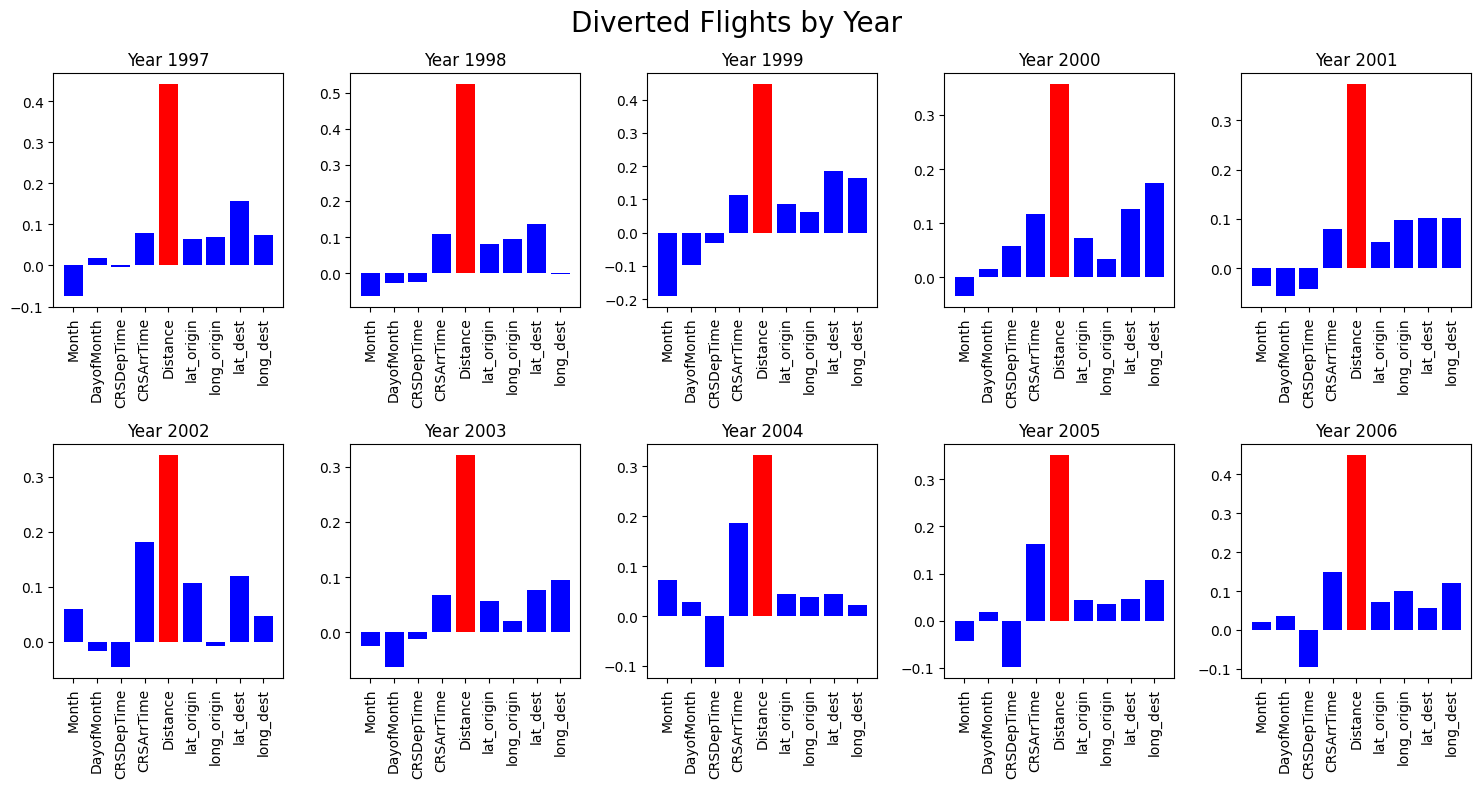

In [6]:
fig, axs = plt.subplots(2, 5, figsize=(15, 8))
fig.suptitle('Diverted Flights by Year', fontsize=20)


for i, data in enumerate(complete_datas):
    X, y = data.drop('Diverted', axis=1), data['Diverted']

    X = (X-X.mean())/X.std()
    
    model = LogisticRegression(max_iter=10000)
    model.fit(X, y)

    coef = model.coef_[0]

    # plot the coefficients, color the max absolute value of the coefficients red
    axs[i//5, i%5].bar(X.columns, coef, color=np.where(abs(coef) == max(abs(coef)), 'r', 'b'))
    axs[i//5, i%5].set_title(f'Year {i+1997}')
    axs[i//5, i%5].set_xticklabels(X.columns, rotation=90)    

plt.tight_layout()
plt.show()

    